# Homework 5 Problem 2: Swin Fine-Tuning vs. Scratch

**Course:** ECGR 4106  
**Student:** Gilberto Feliu  
**Student ID:** 801257813  
**Dataset:** CIFAR-100

This notebook reports the current Problem 2 experiment artifacts from `Results_Problem_2`. All three planned Swin rows were completed for five epochs using 224 by 224 CIFAR-100 inputs.

## Experiment Setup

The pretrained Swin-Tiny and Swin-Small models are loaded with Hugging Face `SwinForImageClassification`, their classifier heads are replaced for 100 classes, and the backbone parameters are frozen so only the classifier head is trained. CIFAR-100 images are resized to 224 by 224 for the Swin inputs.

The scratch model uses `torchvision.models.swin_t(weights=None)` with a 100-class head and all parameters trainable. The scratch run uses 224 by 224 CIFAR-100 inputs, batch size 32, and a 5-epoch CUDA schedule.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd()
RESULTS = ROOT / 'Results_Problem_2'
history_path = RESULTS / 'problem2_history.csv'
summary_path = RESULTS / 'problem2_summary.csv'
plot_path = RESULTS / 'problem2_training_curves.png'
tradeoff_path = RESULTS / 'problem2_tradeoffs.png'
print('Summary:', summary_path)
print('History:', history_path)
print('Training plot:', plot_path)
print('Tradeoff plot:', tradeoff_path)

Summary: /home/gilberto/Homework_5/Results_Problem_2/problem2_summary.csv
History: /home/gilberto/Homework_5/Results_Problem_2/problem2_history.csv
Training plot: /home/gilberto/Homework_5/Results_Problem_2/problem2_training_curves.png
Tradeoff plot: /home/gilberto/Homework_5/Results_Problem_2/problem2_tradeoffs.png


## Summary Results

The table below is read directly from `Results_Problem_2/problem2_summary.csv`.

In [2]:
summary_df = pd.read_csv(summary_path, keep_default_na=False)
summary_df

,model_name,pretrained,frozen_backbone,total_parameter_count,parameter_count,train_time_per_epoch_sec,final_train_loss,final_val_loss,test_accuracy_pct,notes
0,swin_tiny_pretrained,True,True,27596254,76900.0,166.316510,1.803374,1.700253,64.78,"device=cuda,image_size=224,batch_size=32"
1,swin_small_pretrained,True,True,48914158,76900.0,254.732639,1.588867,1.491849,68.74,"device=cuda,image_size=224,batch_size=32"
2,swin_scratch,False,False,27596254,27596254.0,656.553328,4.609511,4.608738,1.00,"device=cuda,image_size=224,batch_size=32"


## Clean Report Table

In [3]:
report_cols = [
    'model_name', 'pretrained', 'frozen_backbone', 'total_parameter_count', 'parameter_count',
    'train_time_per_epoch_sec', 'final_val_loss', 'test_accuracy_pct', 'notes'
]
report_df = summary_df[report_cols].copy()
report_df.columns = ['Model', 'Pretrained', 'Frozen Backbone', 'Total Params', 'Trainable Params', 'Time / Epoch (s)', 'Final Val Loss', 'Test Accuracy (%)', 'Status']
report_df

,Model,Pretrained,Frozen Backbone,Total Params,Trainable Params,Time / Epoch (s),Final Val Loss,Test Accuracy (%),Status
0,swin_tiny_pretrained,True,True,27596254,76900.0,166.316510,1.700253,64.78,"device=cuda,image_size=224,batch_size=32"
1,swin_small_pretrained,True,True,48914158,76900.0,254.732639,1.491849,68.74,"device=cuda,image_size=224,batch_size=32"
2,swin_scratch,False,False,27596254,27596254.0,656.553328,4.608738,1.00,"device=cuda,image_size=224,batch_size=32"


## Per-Epoch History

A full Problem 2 run produces 15 data rows: 3 models times 5 epochs. The current history file has all 15 rows.

In [4]:
history_df = pd.read_csv(history_path)
print(f'History rows: {len(history_df)}')
history_df

History rows: 15


,model_name,epoch,train_loss,val_loss,train_accuracy_pct,val_accuracy_pct,epoch_seconds
0,swin_tiny_pretrained,1,4.098450,3.590238,24.022,45.22,161.356180
1,swin_tiny_pretrained,2,3.183871,2.812997,52.116,56.50,165.039940
2,swin_tiny_pretrained,3,2.530933,2.279206,59.550,60.58,166.882052
3,swin_tiny_pretrained,4,2.091469,1.929768,62.910,63.43,169.117506
4,swin_tiny_pretrained,5,1.803374,1.700253,64.990,64.78,169.184381
5,swin_small_pretrained,1,4.027094,3.461553,27.512,50.59,246.926304
6,swin_small_pretrained,2,3.014689,2.610603,56.930,61.42,252.478911
7,swin_small_pretrained,3,2.311461,2.051200,63.410,65.08,256.316887
8,swin_small_pretrained,4,1.865097,1.706521,66.168,67.16,258.433726
9,swin_small_pretrained,5,1.588867,1.491849,68.028,68.74,259.503115


## Training and Tradeoff Figures

### Loss and Accuracy Curves

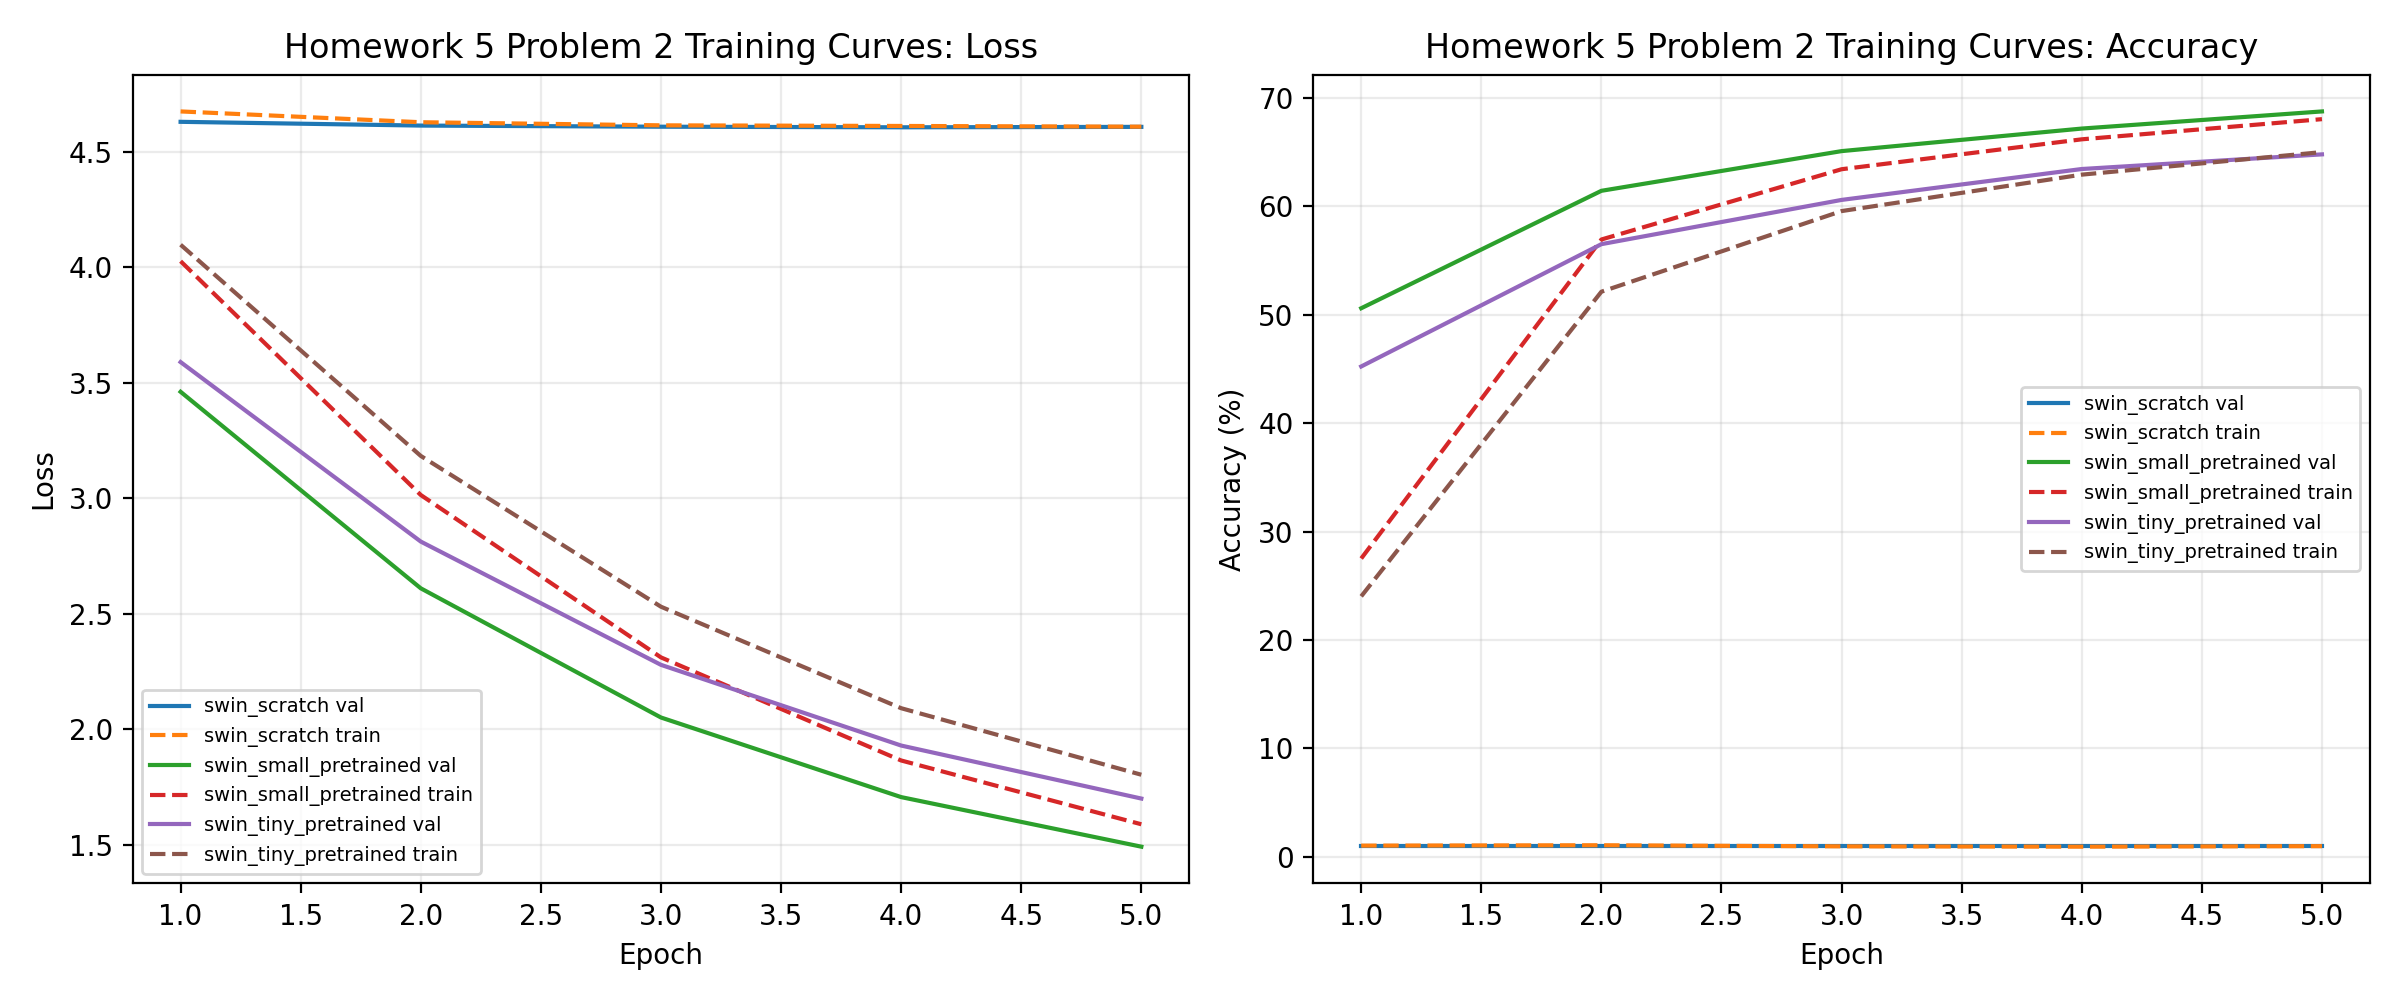

### Accuracy, Runtime, and Fine-Tuning Tradeoffs

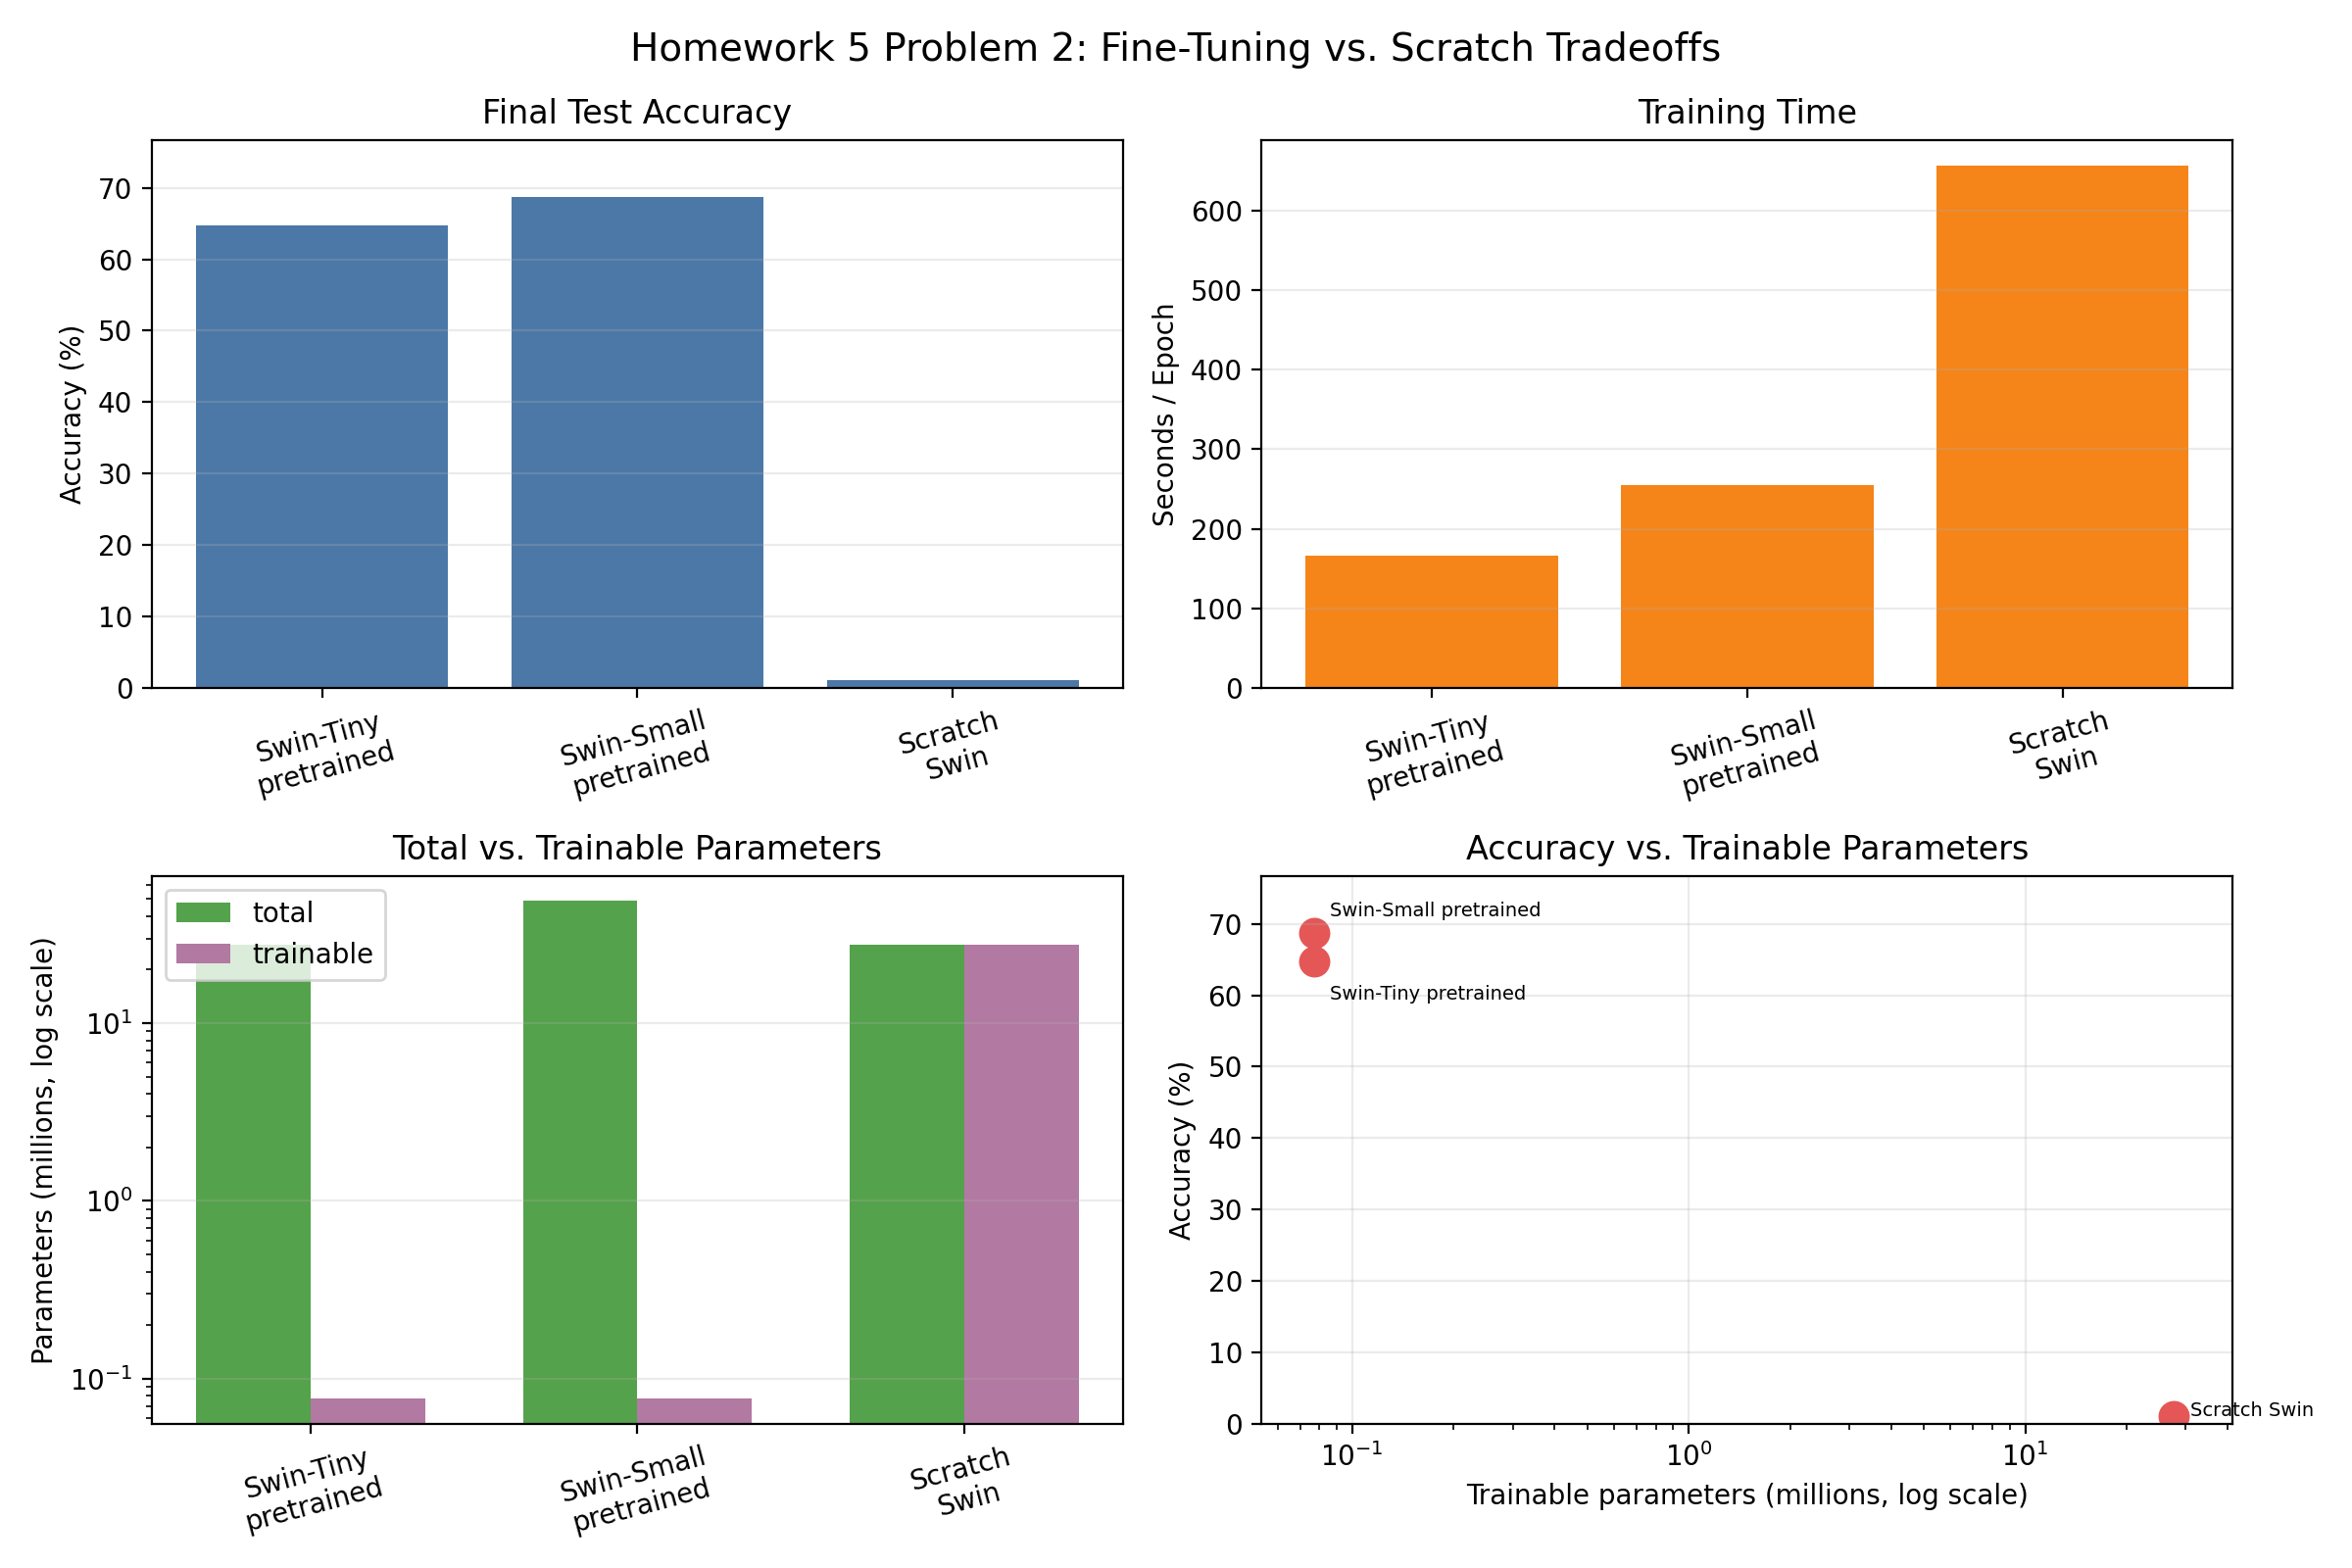

In [5]:
display(Markdown('### Loss and Accuracy Curves'))
display(Image(filename=str(plot_path)))
display(Markdown('### Accuracy, Runtime, and Fine-Tuning Tradeoffs'))
display(Image(filename=str(tradeoff_path)))

## Interpretation

The completed pretrained rows show strong transfer-learning performance after five epochs. Swin-Tiny reaches 64.78% accuracy and Swin-Small reaches 68.74% accuracy. Swin-Small has the better validation loss and test accuracy in the current artifacts, but it also has a larger total parameter count and higher time per epoch.

Scratch Swin stays near chance accuracy, reaching 1.00% accuracy after five CUDA epochs using 224 by 224 inputs. Its loss remains near ln(100), or about 4.605, which is what we expect for chance-level prediction over 100 classes. The plotted curves verify the training behavior: pretrained Swin losses fall and validation accuracy climbs, while scratch Swin stays flat. That is much lower than the pretrained Swin rows, which supports the transfer-learning advantage under a short schedule.